# Analysis of Customer data for Sprocket Central Pty Ltd 

<p>We are analysing customer data with objective of finding pattern in their demographies, purchase behaviour and geographical parameters to group customers for Marketing team for effective management.</p>

In [1233]:
# import common libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import datetime as dt
from sklearn import preprocessing

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

### 1. Load Data and Clean

<p> We have 4 raw data files provided by client (Sprocket Central). We will load and clean the data before proceeding further</p> 

In [1234]:
#import the data from excel raw data transactions file.
#This file contains transactions of existing customers over a period of 3 months.

df_transactions = pd.read_excel("KPMG\KPMG_final.xlsx",sheet_name="Transactions")


In [1235]:
df_transactions.shape

(20000, 13)

In [1236]:
#checking the number nulls in each column
df_transactions.isna().sum()

transaction_id               0
product_id                   0
customer_id                  0
transaction_date             0
online_order               360
order_status                 0
brand                      197
product_line               197
product_class              197
product_size               197
list_price                   0
standard_cost              197
product_first_sold_date    197
dtype: int64

We observe that there are 20,000 transactions recorded with some transactions without a mention of brand and associated descriptions. But since all records have product_id associated with them , for now we will proceed to consider all values as is.

Looking at above dataframe , for now we will ignore the nulls in feature columns . However this is not suggested. </p>
<p>Further, We need to do below to clean the data in this table.</p>
<ul>
    <li> Change the product_first_sold_date column to date type. However as we dont need the column we will drop the column </li> </ul>

In [1237]:
df_transactions['product_first_sold_date'] = pd.to_datetime(df_transactions['product_first_sold_date'], format='%m%d%Y.0', errors='coerce')


In [1238]:
df_transactions.dtypes

transaction_id                      int64
product_id                          int64
customer_id                         int64
transaction_date           datetime64[ns]
online_order                      float64
order_status                       object
brand                              object
product_line                       object
product_class                      object
product_size                       object
list_price                        float64
standard_cost                     float64
product_first_sold_date    datetime64[ns]
dtype: object

In [1239]:
df_transactions.head(2)

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
0,1,2,2950,2017-02-25,0.0,Approved,Solex,Standard,medium,medium,71.49,53.62,NaT
1,2,3,3120,2017-05-21,1.0,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,NaT


In [1240]:
#import the Customer Address data from excel raw data file 

df_custadd = pd.read_excel("KPMG\KPMG_final.xlsx",sheet_name="CustomerAddress")

In [1241]:
df_custadd.shape

(3999, 6)

In [1242]:
df_custadd.isnull().sum()

customer_id           0
address               0
postcode              0
state                 0
country               0
property_valuation    0
dtype: int64

In [1243]:
df_custadd.head(2)

,customer_id,address,postcode,state,country,property_valuation
0,1,060 Morning Avenue,2016,New South Wales,Australia,10
1,2,6 Meadow Vale Court,2153,New South Wales,Australia,10


In [1244]:
#import the Customer Demographic data from excel raw data file 

df_custdemo = pd.read_excel("KPMG\KPMG_final.xlsx",sheet_name="CustomerDemographic")

In [1245]:
df_custdemo.shape

(4000, 13)

In [1246]:
df_custdemo.isnull().sum()

customer_id                              0
first_name                               0
last_name                              125
gender                                   0
past_3_years_bike_related_purchases      0
DOB                                     87
job_title                              506
job_industry_category                  656
wealth_segment                           0
deceased_indicator                       0
default                                302
owns_car                                 0
tenure                                  87
dtype: int64

In [1247]:
df_custdemo.head(2)

,customer_id,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,default,owns_car,tenure
0,1,Laraine,Medendorp,F,93,1953-10-12,Executive Secretary,Health,Mass Customer,N,"""'",Yes,11.0
1,2,Eli,Bockman,Male,81,1980-12-16,Administrative Officer,Financial Services,Mass Customer,N,<script>alert('hi')</script>,Yes,16.0


In [1248]:
df_custdemo.gender.unique()

array(['F', 'Male', 'Female', 'U', 'Femal', 'M'], dtype=object)

We will not change the column with null values for now. However , we will proceed with synchronizing the gender type above. We will consider F for Female and M for Male.

In [1249]:
# Replace all the Female values to F
df_custdemo['gender'] = df_custdemo['gender'].replace(['Femal','Female'],'F')

In [1250]:
# Replace all the Male values to M
df_custdemo['gender'] = df_custdemo['gender'].replace(['Male'],'M')

In [1251]:
df_custdemo['gender'].unique()

array(['F', 'M', 'U'], dtype=object)

In [1252]:
#combine df_custdemo and df_custadd 

In [1253]:
df_cust_old=pd.merge(df_custdemo,df_custadd,how="left",on="customer_id")

In [1254]:
df_cust_old.shape

(4000, 18)

##### NewCustomer dataset load

In [1255]:
#import the data from excel raw data transactions file.
#This file contains transactions of existing customers over a period of 3 months.

df_newcust = pd.read_excel("KPMG\KPMG_final.xlsx",sheet_name="NewCustomerList")

In [1256]:
df_newcust.head(2)

,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,address,postcode,state,country,property_valuation,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Rank,Value
0,Chickie,Brister,Male,86,1957-07-12,General Manager,Manufacturing,Mass Customer,N,Yes,14,45 Shopko Center,4500,QLD,Australia,6,0.40,0.50,0.625,0.53125,1,1,1.71875
1,Morly,Genery,Male,69,1970-03-22,Structural Engineer,Property,Mass Customer,N,No,16,14 Mccormick Park,2113,NSW,Australia,11,0.54,0.54,0.675,0.57375,1,1,1.71875


In [1257]:
df_newcust.isnull().sum()

first_name                               0
last_name                               29
gender                                   0
past_3_years_bike_related_purchases      0
DOB                                     17
job_title                              106
job_industry_category                  165
wealth_segment                           0
deceased_indicator                       0
owns_car                                 0
tenure                                   0
address                                  0
postcode                                 0
state                                    0
country                                  0
property_valuation                       0
Unnamed: 16                              0
Unnamed: 17                              0
Unnamed: 18                              0
Unnamed: 19                              0
Unnamed: 20                              0
Rank                                     0
Value                                    0
dtype: int6

In [1258]:
#We will drop the 4 unnamed columns as we dont know what it represents

df_newcust=df_newcust.drop(['Unnamed: 16','Unnamed: 17','Unnamed: 18','Unnamed: 19','Unnamed: 20'],axis=1)

In [1259]:
df_newcust.head(2)

,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,address,postcode,state,country,property_valuation,Rank,Value
0,Chickie,Brister,Male,86,1957-07-12,General Manager,Manufacturing,Mass Customer,N,Yes,14,45 Shopko Center,4500,QLD,Australia,6,1,1.71875
1,Morly,Genery,Male,69,1970-03-22,Structural Engineer,Property,Mass Customer,N,No,16,14 Mccormick Park,2113,NSW,Australia,11,1,1.71875


### 2. Data Wrangling

##### Preparing old Customer data for next steps i.e segmentation

In [1260]:
df_cust_old.columns

Index(['customer_id', 'first_name', 'last_name', 'gender',
       'past_3_years_bike_related_purchases', 'DOB', 'job_title',
       'job_industry_category', 'wealth_segment', 'deceased_indicator',
       'default', 'owns_car', 'tenure', 'address', 'postcode', 'state',
       'country', 'property_valuation'],
      dtype='object')

In [1261]:
# Add first name and Last name 

df_cust_old['full_name'] = df_cust_old["first_name"] + " " + df_cust_old["last_name"]

In [1262]:
#Get age from DOB column 
# Define function age
from datetime import datetime, date 
def age(born):
    today= date.today()
    return today.year - born.year - ((today.month,  today.day) < (born.month,  born.day)) 


In [1263]:
df_cust_old['Age'] = df_cust_old['DOB'].apply(age) 

In [1264]:
# Check the max value of Age and min value of Age
df_cust_old['Age'].max()

177.0

In [1265]:
 pd.set_option('display.max_columns', 35)

There is one Customer with id 34 with age 177 with DOB in 1843. Not eliminating the row as the member/ member representative has purchases. 

In [1266]:
# Lets convert age column to categorical of groups
category= pd.cut(df_cust_old.Age,bins=[0,20,30,40,50,60,70,80,90,100,200],labels=['Under 20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100','Undefined Age Group'])
df_cust_old.insert(18,'Age-Group',category)

In [1267]:
df_cust_old[['Age','Age-Group']]

,Age,Age-Group
0,67.0,60-70
1,40.0,30-40
2,67.0,60-70
3,59.0,50-60
4,43.0,40-50
...,...,...
3995,45.0,40-50
3996,19.0,Under 20
3997,NaN,NaN
3998,47.0,40-50


In [1268]:
df_cust_old.loc[df_cust_old['Age'] == 177].head(2)

,customer_id,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,default,owns_car,tenure,address,postcode,state,country,property_valuation,Age-Group,full_name,Age
33,34,Jephthah,Bachmann,U,59,1843-12-21,Legal Assistant,IT,Affluent Customer,N,NaN,No,20.0,833 Luster Way,4005.0,QLD,Australia,8.0,Undefined Age Group,Jephthah Bachmann,177.0


In [1269]:
#check distinct values of customer_id column
df_cust_old.customer_id.nunique()

4000

###### Preparing the new customer dataset for next steps

In [1270]:
# Create a new column full name with first name and last name
df_newcust['full name'] = df_newcust["first_name"] + " " + df_newcust["last_name"]

In [1271]:
# Remove the extra spaces
df_newcust['full name']= df_newcust['full name'].str.strip() 

In [1272]:
# REplace the gender with F and M instead of Female and Male

df_newcust.gender.unique()

array(['Male', 'Female', 'U'], dtype=object)

In [1273]:
df_newcust= df_newcust.replace(['Male', 'Female'],['M','F'])

In [1274]:
df_newcust['Age']=df_newcust['DOB'].apply(age)

In [1275]:
# Lets convert age column to categorical of groups
category= pd.cut(df_newcust.Age,bins=[0,20,30,40,50,60,70,80,90,100,200],labels=['Under 20','20-30','30-40','40-50','50-60','60-70','70-80','80-90','90-100','Undefined Age Group'])
df_newcust.insert(18,'Age-Group',category)

In [1276]:
df_newcust.head(2)

,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,address,postcode,state,country,property_valuation,Rank,Value,Age-Group,full name,Age
0,Chickie,Brister,M,86,1957-07-12,General Manager,Manufacturing,Mass Customer,N,Yes,14,45 Shopko Center,4500,QLD,Australia,6,1,1.71875,60-70,Chickie Brister,63.0
1,Morly,Genery,M,69,1970-03-22,Structural Engineer,Property,Mass Customer,N,No,16,14 Mccormick Park,2113,NSW,Australia,11,1,1.71875,50-60,Morly Genery,51.0


In [1277]:
df_newcust.shape

(1000, 21)

### 3. RFM Framework to segment the existing customers based on  Demographic features

<p>To segment the customer , one of the most popular method or framework used in Customer Market Analytics is RFM Framework.</p>

<ul>In RFM framework , we analyze the customer value based on below :
    <li>R stands for Recency meaning How recently did the customer purchase?</li>
    <li>F stands for Frequency meaning How often do Customer purchase</li>
    <li>M stands for Monetary Value meaning How much do they spend</li>
    </ul>
<p> Based on these values, each customer will have a value for R, F and M in the pre-defined time period(In our dataset , we will consider 3 months). For Recency, lower the vaue is better. For Frequency and Monetary, higher the value is better. Following this, we will generate a combined RFM value for each customer and based on the value we will label each customer to a pre-defined label </p>

#### A. Create Customer segments i.e RFM label

##### Preparing Data for RFM framework

In [1278]:
df_transactions.columns

Index(['transaction_id', 'product_id', 'customer_id', 'transaction_date',
       'online_order', 'order_status', 'brand', 'product_line',
       'product_class', 'product_size', 'list_price', 'standard_cost',
       'product_first_sold_date'],
      dtype='object')

In [1279]:
df_transactions_selected = df_transactions[['transaction_id', 'product_id', 'customer_id', 'transaction_date','list_price']].copy()

In [1280]:
df_transactions_selected.shape

(20000, 5)

In [1281]:
#Recency = Last Date in Dataset - Last Transaction Date
#Frequency = Count of Transaction Ids per customer
#Monetary = Sum of Total amount of each customer

In [1282]:
# Checking the first transaction date in the dataset . 

df_transactions_selected['transaction_date'].min()

Timestamp('2017-01-01 00:00:00')

In [1283]:

# Checking the last transaction date in the dataset 

df_transactions_selected['transaction_date'].max()

Timestamp('2017-12-30 00:00:00')

In [1284]:
#This confirms the transactions are over a period of year and out last date that we will consider is
#Create a variable last_date = 2017-12-30
last_date= dt.datetime(2017,12,30)

In [1285]:
# Now we will create R, F and M scores for each customer using aggregated values

R_F_M = df_transactions_selected.groupby('customer_id').agg({'transaction_date':lambda x:(last_date -x.max()).days , 'transaction_id': lambda x: len(x) , 'list_price': lambda x: x.sum()})

In [1286]:
R_F_M.head(5)

,transaction_date,transaction_id,list_price
customer_id,,,
1,7,11,9084.45
2,128,3,4149.07
3,102,8,9888.23
4,195,2,1047.72
5,16,6,5903.20


In [1287]:
#Convert the transaction_date column to int as it represents the number of days . 
R_F_M['transaction_date']=R_F_M['transaction_date'].astype(int)

In [1288]:
#Reset the index
R_F_M.reset_index()

,customer_id,transaction_date,transaction_id,list_price
0,1,7,11,9084.45
1,2,128,3,4149.07
2,3,102,8,9888.23
3,4,195,2,1047.72
4,5,16,6,5903.20
...,...,...,...,...
3489,3497,52,3,3744.07
3490,3498,127,6,5177.06
3491,3499,51,7,7673.48
3492,3500,144,6,4922.41


In [1289]:
#Change the column names

R_F_M.rename(columns={'transaction_date':'Recency','transaction_id':'Frequency','list_price':'Monetary'},inplace= True)

In [1290]:
R_F_M.reset_index().head(5)

,customer_id,Recency,Frequency,Monetary
0,1,7,11,9084.45
1,2,128,3,4149.07
2,3,102,8,9888.23
3,4,195,2,1047.72
4,5,16,6,5903.20


In [1291]:
#Analysing the R, F and M individually and w.r.t each other
# Descriptive status of Recency

R_F_M.Recency.describe()

count    3494.000000
mean       60.813681
std        57.787120
min         0.000000
25%        17.000000
50%        44.000000
75%        85.000000
max       353.000000
Name: Recency, dtype: float64

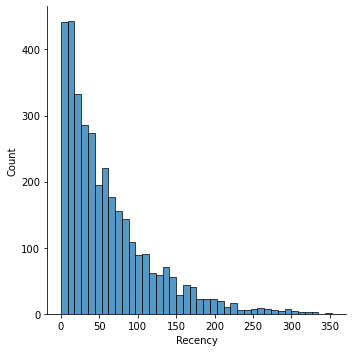

In [1292]:
#Plot the Recency distribution plot 
# The plot means around 400 transactions identified as Recency were within last 10 days.
x= R_F_M['Recency']
ax=sns.displot(x)

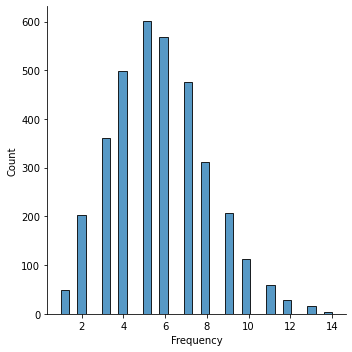

In [1293]:
#Plot the Fequency distribution plot 
#Around 600 customers had 5 transactions within time frame
x= R_F_M['Frequency']
ax=sns.displot(x)


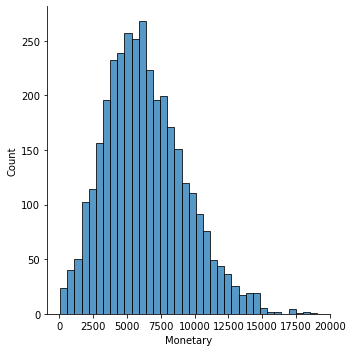

In [1294]:
#Plot the Monetary distribution plot 
#Maximum number of customers had transactions worth monetary value of 5000 to 7500.
x= R_F_M['Monetary']
ax=sns.displot(x)


##### Creating 5 quantiles i.e Segments for identifying 5 types of R,F and M values

Split the records into specific number of Quantiles which represents the number of segments. This is done as per Business Case.
For the particular dataset we have around 3400 customer records . Hence we will divide them into 5 quantiles

In [1295]:
quantiles = R_F_M.quantile(q=[0.2,0.4,0.6,0.8])


In [1296]:
type(quantiles)

pandas.core.frame.DataFrame

In [1297]:
# Quantile's boundary values
quantiles

,Recency,Frequency,Monetary
0.2,14.0,4.0,3812.132
0.4,32.0,5.0,5306.868
0.6,58.0,6.0,6782.248
0.8,98.0,8.0,8764.250


C:\Users\User\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


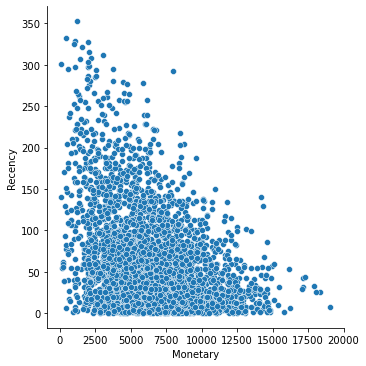

In [1298]:
#Creating Relation Plot Recency vs Monetory
x=R_F_M['Monetary']
y=R_F_M['Recency']
ax=sns.relplot(x,y)


# We can conclude from below scatter plot that customer with recent purchases have led to larger monetary value.

C:\Users\User\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


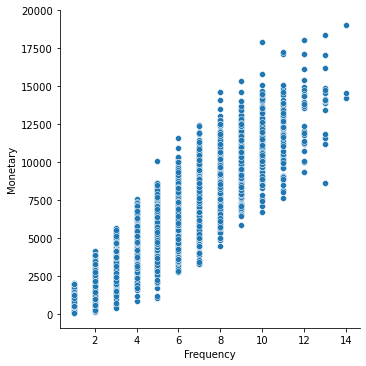

In [1299]:
# Plot Recency vs Monetary

x=R_F_M['Frequency']
y=R_F_M['Monetary']
ax=sns.relplot(x,y)

#The graph indicates that customer with higher frequency value has higher monetary value.

In [1300]:
#Create function to divide R , F and M segments
#For R = 5 repreesnts a record that occured later than R=1
def R_func(x,p,d):
    if x <= d[p][0.2]:
         return 5
    elif x <= d[p][0.4]:
        return 4
    elif x <= d[p][0.6]:
        return 3
    elif x<= d[p][0.8]:
        return 2
    else:
        return 1
    
# For M and F M,F=5 is better than M,F=1

def F_M_func(x,p,d):  
    if x <= d[p][0.2]:
         return 1
    elif x <= d[p][0.4]:
        return 2
    elif x <= d[p][0.6]:
        return 3
    elif x<= d[p][0.8]:
        return 4
    else:
        return 5



In [1301]:
# Generate R_score,F_score and M_score

R_F_M['R_score']= R_F_M['Recency'].apply(R_func,args=('Recency',quantiles))
R_F_M['F_score']= R_F_M['Frequency'].apply(F_M_func,args=('Frequency',quantiles))
R_F_M['M_score']= R_F_M['Monetary'].apply(F_M_func,args=('Monetary',quantiles))

In [1302]:
R_F_M.tail(2)

,Recency,Frequency,Monetary,R_score,F_score,M_score
customer_id,,,,,,
3500,144,6,4922.41,1,3,2
5034,84,3,1519.92,2,1,1


In [1303]:
# Calculate combined RFM_score by adding each value .
R_F_M['RFM_score']=R_F_M[['R_score','F_score','M_score']].sum(axis=1)

In [1304]:
#Also create a group , just a concatenated value of R, F and M. This is necessary for identifying group later
R_F_M['RFM_group'] = R_F_M.R_score.map(str) +R_F_M.F_score.map(str) + R_F_M.M_score.map(str)

In [1305]:
R_F_M.head(5)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_group
customer_id,,,,,,,,
1,7,11,9084.45,5,5,5,15,555
2,128,3,4149.07,1,1,2,4,112
3,102,8,9888.23,1,4,5,10,145
4,195,2,1047.72,1,1,1,3,111
5,16,6,5903.20,4,3,3,10,433


##### Set up Customer segments

Set up customer segment label . We have created 5 segments. 
<ol> 
The labels can be :
    <li>Platinum Customer: These are customers who recently purchased and frequently purchases the products with significant price</li>
    <li>Loyal Customer:These are customers who recently purchased the products with significant price. They are less frequent than Platinium customer </li>
    <li>Sober Customer: These customers frequently purchase products comparitively of low price.</li>
    <li>Evasive Customer : The havent purchased from long time </li>
    <li>High Risk to Lose Customer: They have not purchased from long time , but in past has purchased expensive products.Hence these customers should not be lost</li>
</ol>    
    

In [1306]:
R_F_M.reset_index().head(6)

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_group
0,1,7,11,9084.45,5,5,5,15,555
1,2,128,3,4149.07,1,1,2,4,112
2,3,102,8,9888.23,1,4,5,10,145
3,4,195,2,1047.72,1,1,1,3,111
4,5,16,6,5903.20,4,3,3,10,433
5,6,64,5,5931.69,2,2,3,7,223


In [1307]:
R_F_M.RFM_group.unique()

array(['555', '112', '145', '111', '433', '223', '455', '233', '334',
       '333', '243', '444', '311', '332', '124', '522', '413', '524',
       '245', '544', '144', '511', '211', '345', '155', '212', '312',
       '355', '533', '253', '344', '322', '324', '445', '545', '523',
       '343', '542', '411', '134', '323', '122', '434', '422', '132',
       '244', '512', '222', '232', '443', '331', '554', '454', '123',
       '255', '213', '335', '133', '543', '412', '113', '254', '534',
       '421', '242', '431', '234', '423', '432', '424', '143', '354',
       '435', '313', '235', '353', '224', '532', '513', '221', '521',
       '535', '154', '442', '321', '214', '135', '531', '121', '114',
       '441', '514', '131', '342', '341', '553', '125', '414', '142',
       '541', '453', '231', '241'], dtype=object)

<p>We will manually assign the RFM_group to each label based on our Business scenario.  </p>
<ol>
<li>Platinium:
 '545',  '445', '544', '345', '555',  '355', '453' , '534' ,  '444',   '455',  '533',  '454' ,'543', '435', '554', '535', '525' </li>

<li>Loyal:
'423', '342', '313', '353', '424',   '413', '335', '414', '354', '514', '434',  '254', '532', '433', '334','343' ,
     '524',  '333', '443',  '344', '324' </li>

<li> Sober :
 '512', '511', '431', '441', '531', '341', '542',  '422', '432' ,'411', , '412', '312', '331', '523', '323', '522', '321', '311', '332', '322', '513', '521', '421','442' </li>

<li> Evasive
'233', '122', '213', '111', '133' ,  '123', '142', '211' , '222', '112','243', '143', '212',
       '221',  '231',   '232',  '132', '113', '121', '242' , '131','241',  '141'</li>

<li>High Risk losers :
'153',  '214',  '235', '255', '244', '224', '124', '155', '245', '145',  '144' , '234' , '154' , '134', '223',  '135','114', '253' </li>
 </ol>

In [1308]:
#create Platinium label
plat=['545',  '445', '544', '345', '555',  '355', '453' , '534' ,  '444',   '455',  '533',  '454' ,'543', '435', '554', '535', '525']
R_F_M.loc[R_F_M['RFM_group'].isin(plat), 'RFM_labels'] = 'Platinium'  

In [1309]:
#Check the platinum ones
R_F_M[R_F_M['RFM_labels']=='Platinium'].RFM_group.unique()



array(['555', '455', '444', '544', '345', '355', '533', '445', '545',
       '554', '454', '543', '534', '435', '535', '453'], dtype=object)

In [1310]:
lyl = ['423', '342', '313', '353', '424',   '413', '335', '414', '354', '514', '434',  '254', '532', '433', '334','343' ,'524',  '333', '443',  '344', '324']
R_F_M.loc[R_F_M['RFM_group'].isin(lyl), 'RFM_labels'] = 'Loyal'  

In [1311]:
R_F_M[R_F_M['RFM_labels']=='Loyal'].RFM_group.unique()

array(['433', '334', '333', '413', '524', '344', '324', '343', '434',
       '443', '335', '254', '423', '424', '354', '313', '353', '532',
       '514', '342', '414'], dtype=object)

In [1312]:
sbr = [ '512', '511', '431', '441', '531', '341', '542',  '422', '432' ,'411', '412', '312', '331', '523', '323', '522', '321', '311', '332', '322', '513', '521', '421','442']
R_F_M.loc[R_F_M['RFM_group'].isin(sbr), 'RFM_labels'] = 'Sober' 

In [1313]:
R_F_M[R_F_M['RFM_labels']=='Sober'].RFM_group.unique()

array(['311', '332', '522', '511', '312', '322', '523', '542', '411',
       '323', '422', '512', '331', '412', '421', '431', '432', '513',
       '521', '442', '321', '531', '441', '341'], dtype=object)

In [1314]:
eva = ['233', '122', '213', '111', '133' ,  '123', '142', '211' , '222', '112','243', '143', '212','221',  '231',   '232',  '132', '113', '121', '242' , '131','241',  '141']
R_F_M.loc[R_F_M['RFM_group'].isin(eva), 'RFM_labels'] = 'Evasive' 

In [1315]:
R_F_M[R_F_M['RFM_labels']=='Evasive'].RFM_group.unique()

array(['112', '111', '233', '243', '211', '212', '122', '132', '222',
       '232', '123', '213', '133', '113', '242', '143', '221', '121',
       '131', '142', '231', '241'], dtype=object)

In [1316]:
hrl = ['153',  '214',  '235', '255', '244', '224', '124', '155', '245', '145',  '144' , '234' , '154' , '134', '223',  '135','114', '253']
R_F_M.loc[R_F_M['RFM_group'].isin(hrl), 'RFM_labels'] = 'High Risk Losers' 

In [1317]:
R_F_M[R_F_M['RFM_labels']=='High Risk Losers'].RFM_group.unique()

array(['145', '223', '124', '245', '144', '155', '253', '134', '244',
       '255', '234', '235', '224', '154', '214', '135', '114'],
      dtype=object)

In [1318]:
R_F_M.head(5)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_group,RFM_labels
customer_id,,,,,,,,,
1,7,11,9084.45,5,5,5,15,555,Platinium
2,128,3,4149.07,1,1,2,4,112,Evasive
3,102,8,9888.23,1,4,5,10,145,High Risk Losers
4,195,2,1047.72,1,1,1,3,111,Evasive
5,16,6,5903.20,4,3,3,10,433,Loyal


####  B. Combining the R_F_M data to visualize

Now that we have identified every customer in one of the segment. We will add this details to Customer_Detail dataframe that we created earlier. 

In [1319]:
#df_custdet has all customer details (demographic and geographic)
df_cust_old.columns

Index(['customer_id', 'first_name', 'last_name', 'gender',
       'past_3_years_bike_related_purchases', 'DOB', 'job_title',
       'job_industry_category', 'wealth_segment', 'deceased_indicator',
       'default', 'owns_car', 'tenure', 'address', 'postcode', 'state',
       'country', 'property_valuation', 'Age-Group', 'full_name', 'Age'],
      dtype='object')

In [1320]:
df_cust_old_label =pd.merge(df_cust_old,R_F_M,how="left",on="customer_id")

In [1321]:
df_cust_old_label.head(5)

,customer_id,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,default,owns_car,tenure,address,postcode,state,country,property_valuation,Age-Group,full_name,Age,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_group,RFM_labels
0,1,Laraine,Medendorp,F,93,1953-10-12,Executive Secretary,Health,Mass Customer,N,"""'",Yes,11.0,060 Morning Avenue,2016.0,New South Wales,Australia,10.0,60-70,Laraine Medendorp,67.0,7.0,11.0,9084.45,5.0,5.0,5.0,15.0,555,Platinium
1,2,Eli,Bockman,M,81,1980-12-16,Administrative Officer,Financial Services,Mass Customer,N,<script>alert('hi')</script>,Yes,16.0,6 Meadow Vale Court,2153.0,New South Wales,Australia,10.0,30-40,Eli Bockman,40.0,128.0,3.0,4149.07,1.0,1.0,2.0,4.0,112,Evasive
2,3,Arlin,Dearle,M,61,1954-01-20,Recruiting Manager,Property,Mass Customer,N,2018-02-01 00:00:00,Yes,15.0,NaN,NaN,NaN,NaN,NaN,60-70,Arlin Dearle,67.0,102.0,8.0,9888.23,1.0,4.0,5.0,10.0,145,High Risk Losers
3,4,Talbot,NaN,M,33,1961-10-03,NaN,IT,Mass Customer,N,() { _; } >_[$($())] { touch /tmp/blns.shellsh...,No,7.0,0 Holy Cross Court,4211.0,QLD,Australia,9.0,50-60,NaN,59.0,195.0,2.0,1047.72,1.0,1.0,1.0,3.0,111,Evasive
4,5,Sheila-kathryn,Calton,F,56,1977-05-13,Senior Editor,NaN,Affluent Customer,N,NIL,Yes,8.0,17979 Del Mar Point,2448.0,New South Wales,Australia,4.0,40-50,Sheila-kathryn Calton,43.0,16.0,6.0,5903.20,4.0,3.0,3.0,10.0,433,Loyal


In [1322]:
df_cust_old_label['customer_status'] = 'Existing'

In [1323]:
df_cust_old_label.columns

Index(['customer_id', 'first_name', 'last_name', 'gender',
       'past_3_years_bike_related_purchases', 'DOB', 'job_title',
       'job_industry_category', 'wealth_segment', 'deceased_indicator',
       'default', 'owns_car', 'tenure', 'address', 'postcode', 'state',
       'country', 'property_valuation', 'Age-Group', 'full_name', 'Age',
       'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score',
       'RFM_score', 'RFM_group', 'RFM_labels', 'customer_status'],
      dtype='object')

In [1324]:
df_cust_old_label.shape

(4000, 31)

In [1325]:
df_cust_old_label.head(2)

,customer_id,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,default,owns_car,tenure,address,postcode,state,country,property_valuation,Age-Group,full_name,Age,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_group,RFM_labels,customer_status
0,1,Laraine,Medendorp,F,93,1953-10-12,Executive Secretary,Health,Mass Customer,N,"""'",Yes,11.0,060 Morning Avenue,2016.0,New South Wales,Australia,10.0,60-70,Laraine Medendorp,67.0,7.0,11.0,9084.45,5.0,5.0,5.0,15.0,555,Platinium,Existing
1,2,Eli,Bockman,M,81,1980-12-16,Administrative Officer,Financial Services,Mass Customer,N,<script>alert('hi')</script>,Yes,16.0,6 Meadow Vale Court,2153.0,New South Wales,Australia,10.0,30-40,Eli Bockman,40.0,128.0,3.0,4149.07,1.0,1.0,2.0,4.0,112,Evasive,Existing


##### Monetary Value disctribution across Age-Groups

In [1326]:
df_cust_old_label['Age-Group'].unique()

['60-70', '30-40', '50-60', '40-50', '20-30', 'Under 20', 'Undefined Age Group', NaN, '70-80', '80-90']
Categories (9, object): ['Under 20' < '20-30' < '30-40' < '40-50' ... '60-70' < '70-80' < '80-90' < 'Undefined Age Group']

<Figure size 720x1440 with 0 Axes>

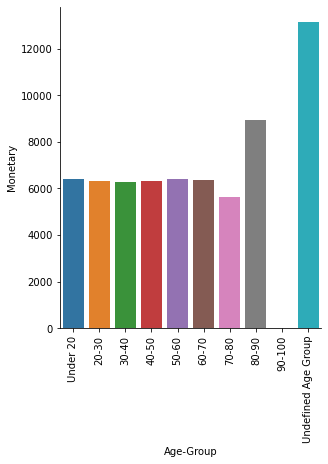

In [1327]:
# Contribution of each Age Group to the total Monetary value

cat1=['60-70', '30-40', '50-60', '40-50', '20-30', 'Under 20', 'Undefined Age Group', '70-80', '80-90']
da=df_cust_old_label[(df_cust_old_label["Age-Group"].isin(cat1))]
da1= da[(df_cust_old_label.notnull())]


# Changing Seaborn Plot size
plt.figure(figsize=(10,20))

chart =sns.catplot(data=da1, x='Age-Group', y='Monetary', kind='bar',ci=None  )

chart.set_xticklabels(rotation=90)


##### Monetary Value distribution across gender

In [1328]:
df_cust_old_label['gender'].unique()

array(['F', 'M', 'U'], dtype=object)

<Figure size 720x1440 with 0 Axes>

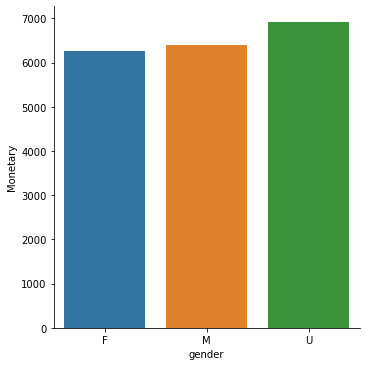

In [1329]:
# Contribution of each Age Group to the total Monetary value

cat7=['F', 'M', 'U']
da=df_cust_old_label[(df_cust_old_label["gender"].isin(cat7))]
da1= da[(df_cust_old_label.notnull())]


# Changing Seaborn Plot size
plt.figure(figsize=(10,20))

chart =sns.catplot(data=da1, x='gender', y='Monetary', kind='bar',ci=None  )




In [1330]:
##### Monetary value distribution across wealth segments

In [1331]:
df_cust_old_label['wealth_segment'].unique()

array(['Mass Customer', 'Affluent Customer', 'High Net Worth'],
      dtype=object)

<Figure size 720x1440 with 0 Axes>

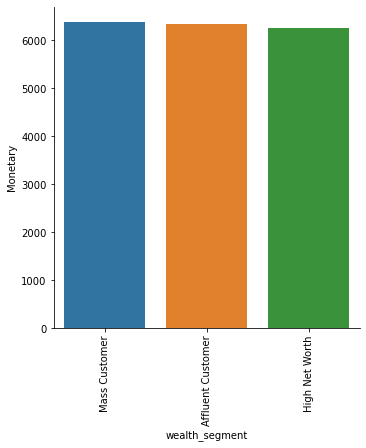

In [1332]:
# Contribution of each Job industrywealth segment category to the total Monetary value


cat2=['Mass Customer', 'Affluent Customer', 'High Net Worth']
da=df_cust_old_label[(df_cust_old_label["wealth_segment"].isin(cat2))]



# Changing Seaborn Plot size
plt.figure(figsize=(10,20))

chart =sns.catplot(data=da1, x='wealth_segment', y='Monetary', kind='bar',ci=None  )

chart.set_xticklabels(rotation=90)

##### Monetary Value distribution across varios Job industries of Customers

In [1333]:
df_cust_old_label['job_industry_category'].unique()

array(['Health', 'Financial Services', 'Property', 'IT', nan, 'Retail',
       'Argiculture', 'Manufacturing', 'Telecommunications',
       'Entertainment'], dtype=object)

<Figure size 720x1440 with 0 Axes>

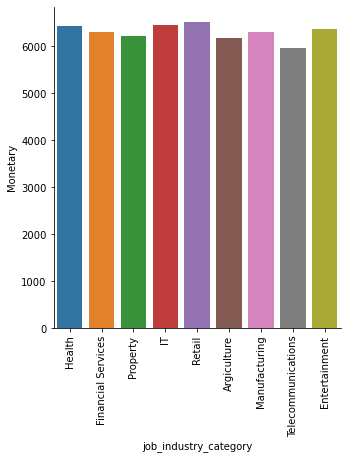

In [1334]:
# Contribution of each gender to the total Monetary value
cat3=['Health', 'Financial Services', 'Property', 'IT', 'Retail','Argiculture', 'Manufacturing', 'Telecommunications','Entertainment']
da=df_cust_old_label[(df_cust_old_label["job_industry_category"].isin(cat3))]
da1= da[(df_cust_old_label.notnull())]


# Changing Seaborn Plot size
plt.figure(figsize=(10,20))

chart =sns.catplot(data=da1, x='job_industry_category', y='Monetary', kind='bar',ci=None  )

chart.set_xticklabels(rotation=90)

##### Monetary Value distribution across life-style (whether a Customer owns a car and yet uses bicycle products)

In [1335]:
df_cust_old_label['owns_car'].unique()

array(['Yes', 'No'], dtype=object)

<Figure size 720x1440 with 0 Axes>

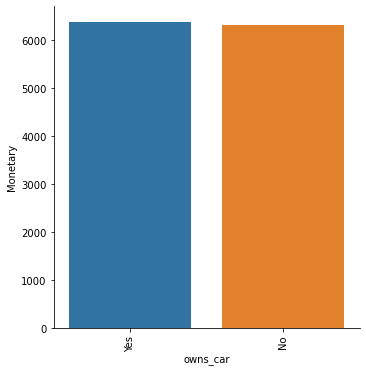

In [1336]:
# Contribution of each Job industry category to the total Monetary value
# Contribution of each gender to the total Monetary value
cat4=['Yes', 'No']
da=df_cust_old_label[(df_cust_old_label["owns_car"].isin(cat4))]
da1= da[(df_cust_old_label.notnull())]


# Changing Seaborn Plot size
plt.figure(figsize=(10,20))

chart =sns.catplot(data=da1, x='owns_car', y='Monetary', kind='bar',ci=None  )

chart.set_xticklabels(rotation=90)

##### Value across geography (State)

In [1337]:
df_cust_old_label['state'].unique()

array(['New South Wales', nan, 'QLD', 'VIC', 'NSW', 'Victoria'],
      dtype=object)

<Figure size 720x1440 with 0 Axes>

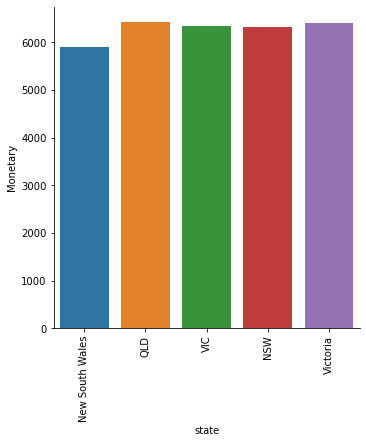

In [1338]:
# Contribution of each state to the total Monetary value per gender
cat5=['New South Wales', 'QLD', 'VIC', 'NSW', 'Victoria']
da=df_cust_old_label[(df_cust_old_label["state"].isin(cat5))]
da1= da[(df_cust_old_label.notnull())]


# Changing Seaborn Plot size
plt.figure(figsize=(10,20))

chart =sns.catplot(data=da1, x='state', y='Monetary', kind='bar',ci=None  )

chart.set_xticklabels(rotation=90)

##### Monetary value distribution across Customer segments

In [1339]:
df_cust_old_label['RFM_labels'].unique()

array(['Platinium', 'Evasive', 'High Risk Losers', 'Loyal', 'Sober', nan],
      dtype=object)

<Figure size 720x1440 with 0 Axes>

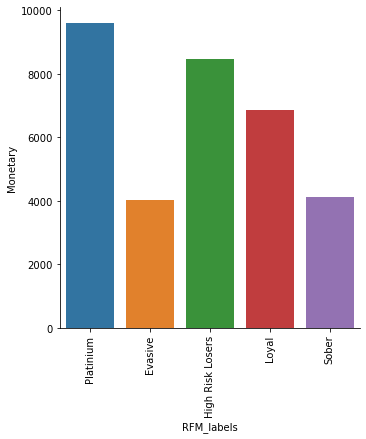

In [1340]:
# Contribution of each RFM_labels to the total Monetary value per gender
cat6=['Platinium', 'Evasive', 'High Risk Losers', 'Loyal', 'Sober']
da=df_cust_old_label[(df_cust_old_label["RFM_labels"].isin(cat6))]
da1= da[(df_cust_old_label.notnull())]


# Changing Seaborn Plot size
plt.figure(figsize=(10,20))

chart =sns.catplot(data=da1, x='RFM_labels', y='Monetary', kind='bar',ci=None  )

chart.set_xticklabels(rotation=90)

In [1341]:
#groupby the data by delivery type
pie_da = df_cust_old_label.groupby("RFM_labels")["Monetary"].sum()
pie_da

RFM_labels
Evasive             3780105.21
High Risk Losers    3631017.97
Loyal               3423591.66
Platinium           8099469.17
Sober               3194974.49
Name: Monetary, dtype: float64

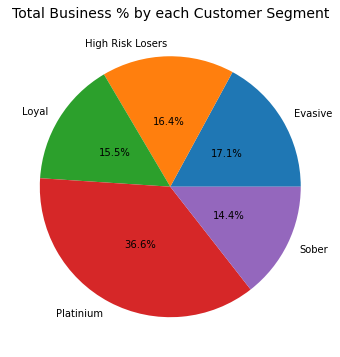

In [1342]:
#Using matplotlib
pie, ax = plt.subplots(figsize=[10,6])
labels = pie_da.keys()
plt.pie(x=pie_da, autopct="%.1f%%", labels=labels, pctdistance=0.5)
plt.title("Total Business % by each Customer Segment", fontsize=14);


From Above , it is clear that the contribution of Platinium labeled customer is maximum with 36.6% as compared to others. High Risk Losers and Evasive losers are on verge of churn .Hence in old customers , we need to target them to bring them to loayalty zone.

###### Total number of customers in each Segment

In [1343]:
df_cust_old_label.groupby('RFM_labels').count()

,customer_id,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,default,owns_car,tenure,address,postcode,state,country,property_valuation,Age-Group,full_name,Age,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_group,customer_status
RFM_labels,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Evasive,940,940,908,940,940,923,813,774,940,940,876,940,923,940,940,940,940,940,923,908,923,940,940,940,940,940,940,940,940,940
High Risk Losers,429,429,411,429,429,423,390,369,429,429,405,429,423,427,427,427,427,427,423,411,423,429,429,429,429,429,429,429,429,429
Loyal,499,499,484,499,499,491,438,422,499,499,468,499,491,498,498,498,498,498,491,484,491,499,499,499,499,499,499,499,499,499
Platinium,843,843,822,843,843,819,739,699,843,843,773,843,819,842,842,842,842,842,819,822,819,843,843,843,843,843,843,843,843,843
Sober,778,778,752,778,778,757,686,664,778,778,713,778,757,778,778,778,778,778,757,752,757,778,778,778,778,778,778,778,778,778


#### C. Prediction Using K Nearest Neighbours

Lets create a feature set . We will create one feature set with demographic features.
Further we will have to standardize the feature set using scikit library. 

In [1344]:
# creating new df with only required columns for prediction
df_cust_old_demographic= df_cust_old_label[['gender','past_3_years_bike_related_purchases','Age-Group','job_industry_category','wealth_segment','property_valuation','tenure','owns_car','RFM_labels']].copy()

In [1345]:
df_cust_old_demographic.shape

(4000, 9)

In [1346]:
#Replace the gender values to integers
df_cust_old_demographic['gender'] = df_cust_old_demographic['gender'].replace(['F','M','U'],[1,2,3])

In [1347]:
df_cust_old_demographic.gender.unique()

array([1, 2, 3], dtype=int64)

In [1348]:
#Replace the values in job_industry_category with integers
df_cust_old_demographic['job_industry_category']= df_cust_old_demographic['job_industry_category'].replace(['Health', 'Financial Services', 'Property', 'IT',  'Retail','Argiculture', 'Manufacturing', 'Telecommunications','Entertainment'],[1,2,3,4,5,6,7,8,9])

In [1349]:
df_cust_old_demographic['job_industry_category']=df_cust_old_demographic['job_industry_category'].fillna(0)

In [1350]:
df_cust_old_demographic.job_industry_category.unique()

array([1., 2., 3., 4., 0., 5., 6., 7., 8., 9.])

In [1351]:
# Replace the values in wealth_segment with numeric
df_cust_old_demographic['wealth_segment']=df_cust_old_demographic['wealth_segment'].replace(['Mass Customer', 'Affluent Customer', 'High Net Worth'],[1,2,3])

In [1352]:
df_cust_old_demographic.wealth_segment.unique()

array([1, 2, 3], dtype=int64)

In [1353]:
#Replace the Age-Group with integers
df_cust_old_demographic['Age-Group']=df_cust_old_demographic['Age-Group'].replace(['Under 20','20-30', '30-40','40-50', '50-60','60-70', '70-80', '80-90',  'Undefined Age Group'],[1,2,3,4,5,6,7,8,9])

In [1354]:
df_cust_old_demographic['Age-Group']=df_cust_old_demographic['Age-Group'].fillna(0)

In [1355]:
df_cust_old_demographic['Age-Group'].unique()

array([6., 3., 5., 4., 2., 1., 9., 0., 7., 8.])

In [1356]:
df_cust_old_demographic['owns_car']=df_cust_old_demographic['owns_car'].replace(['Yes', 'No'],[1,0])

In [1357]:
df_cust_old_demographic.owns_car.unique()

array([1, 0], dtype=int64)

In [1358]:
df_cust_old_demographic.head(2)

,gender,past_3_years_bike_related_purchases,Age-Group,job_industry_category,wealth_segment,property_valuation,tenure,owns_car,RFM_labels
0,1,93,6.0,1.0,1,10.0,11.0,1,Platinium
1,2,81,3.0,2.0,1,10.0,16.0,1,Evasive


In [1359]:
df_cust_old_demographic.isnull().sum()

gender                                   0
past_3_years_bike_related_purchases      0
Age-Group                                0
job_industry_category                    0
wealth_segment                           0
property_valuation                       4
tenure                                  87
owns_car                                 0
RFM_labels                             511
dtype: int64

In [1360]:
#We see that 2 columns property_valuation and tenure has null values. I will replace both with 0
df_cust_old_demographic['property_valuation']=df_cust_old_demographic['property_valuation'].fillna(0)
df_cust_old_demographic['tenure']=df_cust_old_demographic['tenure'].fillna(0)

In [1361]:
df_cust_old_demographic.isnull().sum()

gender                                   0
past_3_years_bike_related_purchases      0
Age-Group                                0
job_industry_category                    0
wealth_segment                           0
property_valuation                       0
tenure                                   0
owns_car                                 0
RFM_labels                             511
dtype: int64

There are 511 records without label. These might be customers who had no transactions in the period of dataset. Lets filter out these as there is no contribution from these customers in building the model.

In [1362]:
#Filter out only records that have non-null values for RFM_labels
df_cust_old_demographic=df_cust_old_demographic.loc[df_cust_old_demographic['RFM_labels'].notnull(), ['gender','past_3_years_bike_related_purchases','Age-Group','job_industry_category','wealth_segment','property_valuation','tenure','owns_car','RFM_labels' ]]


In [1363]:

df_cust_old_demographic.isnull().sum()

gender                                 0
past_3_years_bike_related_purchases    0
Age-Group                              0
job_industry_category                  0
wealth_segment                         0
property_valuation                     0
tenure                                 0
owns_car                               0
RFM_labels                             0
dtype: int64

Now that we have prepared data . Lets proceed with initializing the feature set and predictor variable as well as the training and test data set.

In [1364]:
Y=df_cust_old_demographic[['RFM_labels']].values

In [1365]:
X=df_cust_old_demographic[['gender','past_3_years_bike_related_purchases', 'job_industry_category', 'wealth_segment', 'owns_car', 'tenure','property_valuation', 'Age-Group']].values

In [1366]:
X.shape

(3489, 8)

###### Normalize the data

Data Standardization give data zero mean and unit variance, it is good practice, especially for algorithms such as KNN which is based on distance of cases

In [1367]:
X = preprocessing.StandardScaler().fit(X).transform(X.astype(float))
X[0:5]

array([[-0.95601792,  1.54527711, -0.88034385, -0.90571831,  0.98548792,
         0.09410238,  0.88051831,  1.62985318],
       [ 0.88886401,  1.1254977 , -0.5190736 , -0.90571831,  0.98548792,
         0.95268815,  0.88051831, -0.53124046],
       [ 0.88886401,  0.42586535, -0.15780334, -0.90571831,  0.98548792,
         0.78097099, -2.6494465 ,  1.62985318],
       [ 0.88886401, -0.55361994,  0.20346691, -0.90571831, -1.01472578,
        -0.59276624,  0.52752183,  0.90948863],
       [-0.95601792,  0.25095726, -1.2416141 ,  0.29217827,  0.98548792,
        -0.42104908, -1.23746058,  0.18912408]])

###### Train-Test Split

In [1368]:
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.1, random_state=4)
print ('Train set:', X_train.shape,  Y_train.shape)
print ('Test set:', X_test.shape,  Y_test.shape)

Train set: (3140, 8) (3140, 1)
Test set: (349, 8) (349, 1)


##### Elbow method to find the K

In [1369]:
error_rate = []
# Will take some time
for i in range(1,50):
 
 knn = KNeighborsClassifier(n_neighbors=i)
 knn.fit(X_train,Y_train)
 pred_i = knn.predict(X_test)
 error_rate.append(np.mean(pred_i != Y_test))

<ipython-input-1369-e87475240e8b>:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  knn.fit(X_train,Y_train)
<ipython-input-1369-e87475240e8b>:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  knn.fit(X_train,Y_train)
<ipython-input-1369-e87475240e8b>:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  knn.fit(X_train,Y_train)
<ipython-input-1369-e87475240e8b>:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  knn.fit(X_train,Y_train)
<ipython-input-1369-e87475240e8b>:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. P

<ipython-input-1369-e87475240e8b>:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  knn.fit(X_train,Y_train)
<ipython-input-1369-e87475240e8b>:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  knn.fit(X_train,Y_train)
<ipython-input-1369-e87475240e8b>:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  knn.fit(X_train,Y_train)
<ipython-input-1369-e87475240e8b>:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  knn.fit(X_train,Y_train)
<ipython-input-1369-e87475240e8b>:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. P

Text(0, 0.5, 'Error Rate')

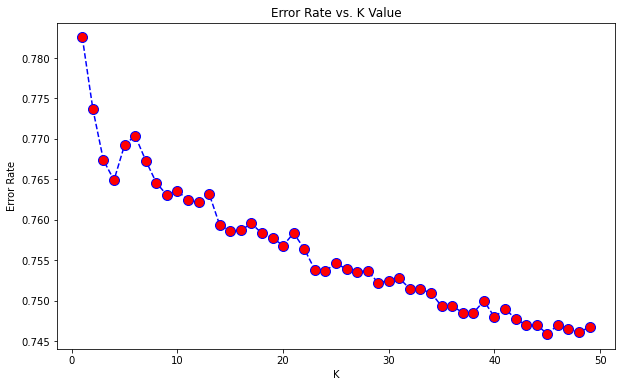

In [1370]:
plt.figure(figsize=(10,6))
plt.plot(range(1,50),error_rate,color='blue', linestyle='dashed', marker='o',
 markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [1371]:
Ks = 50
mean_acc = np.zeros((Ks-1))
std_acc = np.zeros((Ks-1))

for n in range(1,Ks):
    
    #Train Model and Predict  
    demo_model = KNeighborsClassifier(n_neighbors = n).fit(X_train,Y_train)
    Yhat=demo_model.predict(X_test)
    mean_acc[n-1] = metrics.accuracy_score(Y_test, Yhat)

    
    std_acc[n-1]=np.std(Yhat==Y_test)/np.sqrt(Yhat.shape[0])

mean_acc

<ipython-input-1371-31722cfc394f>:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  demo_model = KNeighborsClassifier(n_neighbors = n).fit(X_train,Y_train)
<ipython-input-1371-31722cfc394f>:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  demo_model = KNeighborsClassifier(n_neighbors = n).fit(X_train,Y_train)
<ipython-input-1371-31722cfc394f>:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  demo_model = KNeighborsClassifier(n_neighbors = n).fit(X_train,Y_train)
<ipython-input-1371-31722cfc394f>:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  demo

<ipython-input-1371-31722cfc394f>:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  demo_model = KNeighborsClassifier(n_neighbors = n).fit(X_train,Y_train)
<ipython-input-1371-31722cfc394f>:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  demo_model = KNeighborsClassifier(n_neighbors = n).fit(X_train,Y_train)
<ipython-input-1371-31722cfc394f>:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  demo_model = KNeighborsClassifier(n_neighbors = n).fit(X_train,Y_train)
<ipython-input-1371-31722cfc394f>:8: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  demo

array([0.26074499, 0.24355301, 0.24928367, 0.23782235, 0.26361032,
       0.23782235, 0.24355301, 0.252149  , 0.25501433, 0.27507163,
       0.23782235, 0.23782235, 0.24355301, 0.24928367, 0.24641834,
       0.24355301, 0.25787966, 0.252149  , 0.26074499, 0.28653295,
       0.2722063 , 0.27507163, 0.2722063 , 0.28366762, 0.29226361,
       0.27793696, 0.28939828, 0.28366762, 0.28939828, 0.28939828,
       0.29799427, 0.28653295, 0.31232092, 0.3008596 , 0.29512894,
       0.30659026, 0.29226361, 0.29799427, 0.30372493, 0.29799427,
       0.3008596 , 0.29226361, 0.28653295, 0.29512894, 0.28939828,
       0.29512894, 0.28939828, 0.28080229, 0.28080229])

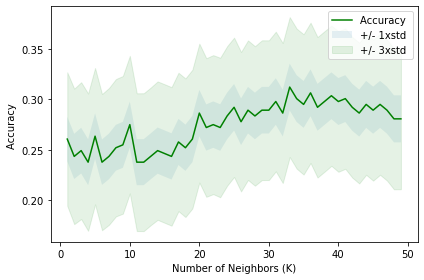

In [1372]:
plt.plot(range(1,Ks),mean_acc,'g')
plt.fill_between(range(1,Ks),mean_acc - 1 * std_acc,mean_acc + 1 * std_acc, alpha=0.10)
plt.fill_between(range(1,Ks),mean_acc - 3 * std_acc,mean_acc + 3 * std_acc, alpha=0.10,color="green")
plt.legend(('Accuracy ', '+/- 1xstd','+/- 3xstd'))
plt.ylabel('Accuracy ')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()

From Above method , the best accuracy with test sample we got with K=33. Hence will go ahead with K=33

In [1373]:
k =33
#Train Model   
demo_model = KNeighborsClassifier(n_neighbors = k).fit(X_train,Y_train)


<ipython-input-1373-a2101880a7c4>:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  demo_model = KNeighborsClassifier(n_neighbors = k).fit(X_train,Y_train)


In [1374]:
demo_model

KNeighborsClassifier(n_neighbors=33)

In [1375]:
Yhat = demo_model.predict(X_test)


In [1376]:
Yhat[0:5]

array(['Evasive', 'Platinium', 'Evasive', 'Evasive', 'Platinium'],
      dtype=object)

In [1377]:

print("Train set Accuracy: ", metrics.accuracy_score(Y_train, demo_model.predict(X_train)))
print("Test set Accuracy: ", metrics.accuracy_score(Y_test, Yhat))

Train set Accuracy:  0.31178343949044585
Test set Accuracy:  0.3123209169054441


Now , we will use the trained model to identify the segment labels of new customers . This will help us to identify which set of new customers are to be focussed on.

##### Preparing the new customer dataset

In [1378]:
df_newcust['RFM_labels']=''

In [1379]:
df_newcust.dtypes

first_name                                     object
last_name                                      object
gender                                         object
past_3_years_bike_related_purchases             int64
DOB                                    datetime64[ns]
job_title                                      object
job_industry_category                          object
wealth_segment                                 object
deceased_indicator                             object
owns_car                                       object
tenure                                          int64
address                                        object
postcode                                        int64
state                                          object
country                                        object
property_valuation                              int64
Rank                                            int64
Value                                         float64
Age-Group                   

In [1380]:
df_cust_new_demographic= df_newcust[['gender','past_3_years_bike_related_purchases','Age-Group','job_industry_category','wealth_segment','property_valuation','tenure','owns_car','RFM_labels']].copy()

In [1381]:
df_cust_new_demographic.shape

(1000, 9)

In [1382]:
#Replace the gender values to integers
df_cust_new_demographic['gender'] = df_cust_new_demographic['gender'].replace(['F','M','U'],[1,2,3])

In [1383]:
df_cust_new_demographic.gender.unique()

array([2, 1, 3], dtype=int64)

In [1384]:
# Replace the values in wealth_segment with numeric
df_cust_new_demographic['wealth_segment']=df_cust_new_demographic['wealth_segment'].replace(['Mass Customer', 'Affluent Customer', 'High Net Worth'],[1,2,3])

In [1385]:
df_cust_new_demographic.wealth_segment.unique()

array([1, 2, 3], dtype=int64)

In [1386]:
#Replace the Age-Group with integers
df_cust_new_demographic['Age-Group']=df_cust_new_demographic['Age-Group'].replace(['Under 20','20-30', '30-40','40-50', '50-60','60-70', '70-80', '80-90',  'Above 100'],[1,2,3,4,5,6,7,8,9])

In [1387]:
df_cust_new_demographic['Age-Group'].unique()

array([ 6.,  5.,  4.,  3.,  2.,  8.,  7., nan,  1.])

In [1388]:
#Replace the values in job_industry_category with integers
df_cust_new_demographic['job_industry_category']= df_cust_new_demographic['job_industry_category'].replace(['Health', 'Financial Services', 'Property', 'IT',  'Retail','Argiculture', 'Manufacturing', 'Telecommunications','Entertainment'],[1,2,3,4,5,6,7,8,9])

In [1389]:
#Replace the Age-Group with integers
df_cust_new_demographic['owns_car']=df_cust_new_demographic['owns_car'].replace(['Yes', 'No'],[1,0])

In [1390]:
df_cust_new_demographic['job_industry_category'].unique()

array([ 7.,  3.,  2.,  9.,  5.,  4.,  8.,  1., nan,  6.])

In [1391]:
df_cust_new_demographic.isnull().sum()

gender                                   0
past_3_years_bike_related_purchases      0
Age-Group                               17
job_industry_category                  165
wealth_segment                           0
property_valuation                       0
tenure                                   0
owns_car                                 0
RFM_labels                               0
dtype: int64

In [1392]:
df_cust_new_demographic['job_industry_category']=df_cust_new_demographic['job_industry_category'].fillna(0)

In [1393]:
df_cust_new_demographic['Age-Group']=df_cust_new_demographic['Age-Group'].fillna(0)

In [1394]:
df_cust_new_demographic.shape

(1000, 9)

##### Predicting the segments for new customer List using trained model

In [1395]:
X_newcust=df_cust_new_demographic[['gender','past_3_years_bike_related_purchases', 'job_industry_category', 'wealth_segment', 'owns_car', 'tenure','property_valuation', 'Age-Group']].values

In [1396]:
Y_newcust=df_cust_new_demographic[['RFM_labels']]

In [1397]:
X_newcust.shape

(1000, 8)

In [1398]:
Y_newcust.shape

(1000, 1)

In [1399]:
X_newcust = preprocessing.StandardScaler().fit(X_newcust).transform(X_newcust.astype(float))


In [1400]:
Y_newcust = demo_model.predict(X_newcust)

In [1401]:
X_newcust.shape

(1000, 8)

In [1402]:
Y_newcust[0:20]

array(['Platinium', 'Evasive', 'Evasive', 'Evasive', 'Evasive', 'Sober',
       'Evasive', 'Evasive', 'Evasive', 'Platinium', 'Sober', 'Evasive',
       'Evasive', 'Evasive', 'Loyal', 'Evasive', 'Evasive', 'Evasive',
       'Evasive', 'Sober'], dtype=object)

In [1403]:
df_cust_new_demographic.dtypes

gender                                   int64
past_3_years_bike_related_purchases      int64
Age-Group                              float64
job_industry_category                  float64
wealth_segment                           int64
property_valuation                       int64
tenure                                   int64
owns_car                                 int64
RFM_labels                              object
dtype: object

In [1404]:
type(Y_newcust)

numpy.ndarray

In [1405]:
Y_new_df=pd.DataFrame(Y_newcust)

In [1406]:
type(Y_new_df)

pandas.core.frame.DataFrame

In [1407]:
Y_new_df.shape

(1000, 1)

In [1408]:
Y_new_df['RFM_labels']=Y_new_df.copy()

In [1409]:
Y_new_df=Y_new_df.drop(0,axis=1)

In [1410]:
Y_new_df.head(10)

,RFM_labels
0,Platinium
1,Evasive
2,Evasive
3,Evasive
4,Evasive
5,Sober
6,Evasive
7,Evasive
8,Evasive
9,Platinium


In [1411]:
df_newcust.shape

(1000, 22)

In [1412]:
df_newcust['RFM_labels']=Y_new_df[['RFM_labels']].copy()

In [1413]:
df_newcust.head(5)

,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,address,postcode,state,country,property_valuation,Rank,Value,Age-Group,full name,Age,RFM_labels
0,Chickie,Brister,M,86,1957-07-12,General Manager,Manufacturing,Mass Customer,N,Yes,14,45 Shopko Center,4500,QLD,Australia,6,1,1.718750,60-70,Chickie Brister,63.0,Platinium
1,Morly,Genery,M,69,1970-03-22,Structural Engineer,Property,Mass Customer,N,No,16,14 Mccormick Park,2113,NSW,Australia,11,1,1.718750,50-60,Morly Genery,51.0,Evasive
2,Ardelis,Forrester,F,10,1974-08-28,Senior Cost Accountant,Financial Services,Affluent Customer,N,No,10,5 Colorado Crossing,3505,VIC,Australia,5,1,1.718750,40-50,Ardelis Forrester,46.0,Evasive
3,Lucine,Stutt,F,64,1979-01-28,Account Representative III,Manufacturing,Affluent Customer,N,Yes,5,207 Annamark Plaza,4814,QLD,Australia,1,4,1.703125,40-50,Lucine Stutt,42.0,Evasive
4,Melinda,Hadlee,F,34,1965-09-21,Financial Analyst,Financial Services,Affluent Customer,N,No,19,115 Montana Place,2093,NSW,Australia,9,4,1.703125,50-60,Melinda Hadlee,55.0,Evasive


In [1414]:
df_newcust.shape

(1000, 22)

In [1415]:
df_newcust['RFM_labels'].unique()

array(['Platinium', 'Evasive', 'Sober', 'Loyal', 'High Risk Losers'],
      dtype=object)

In [1416]:
df_newcust.columns

Index(['first_name', 'last_name', 'gender',
       'past_3_years_bike_related_purchases', 'DOB', 'job_title',
       'job_industry_category', 'wealth_segment', 'deceased_indicator',
       'owns_car', 'tenure', 'address', 'postcode', 'state', 'country',
       'property_valuation', 'Rank', 'Value', 'Age-Group', 'full name', 'Age',
       'RFM_labels'],
      dtype='object')

#### D: Result

Based on Old customer behaviour , we segmented and 'Platinium' group constitutes of customers who spend more frequently, more money as well as most recently. Applying the rule to new customer list ,the prediction will indicate that the Platinium segment in new customers are the one who will bring maximum business and hence the marketing team should target them.

In [1417]:
#filter to get the platinium users
platinium_filt =(df_newcust['RFM_labels']=='Platinium')

In [1418]:
df_newcust_target = df_newcust.loc[platinium_filt,['first_name', 'last_name', 'gender',
       'past_3_years_bike_related_purchases', 'DOB', 'job_title',
       'job_industry_category', 'wealth_segment', 'deceased_indicator',
       'owns_car', 'tenure', 'address', 'postcode', 'state', 'country',
       'property_valuation', 'Rank', 'Value', 'Age-Group', 'full name', 'Age',
       'RFM_labels']]

In [1419]:
df_newcust_target.head(2)

,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,address,postcode,state,country,property_valuation,Rank,Value,Age-Group,full name,Age,RFM_labels
0,Chickie,Brister,M,86,1957-07-12,General Manager,Manufacturing,Mass Customer,N,Yes,14,45 Shopko Center,4500,QLD,Australia,6,1,1.718750,60-70,Chickie Brister,63.0,Platinium
9,Barthel,Docket,M,72,1985-08-02,Accounting Assistant IV,IT,Mass Customer,N,Yes,17,80 Scofield Junction,4151,QLD,Australia,5,10,1.640625,30-40,Barthel Docket,35.0,Platinium


In [1420]:
df_newcust_target.shape

(289, 22)

In [1421]:
# Retriving the target customers to excel
df_newcust_target.to_excel('New Customer Target.xlsx')

##### Visualizing the segment distribution based on count of Customers

In [1428]:
#groupby the data by customer segment
pie_da_new = df_newcust['RFM_labels'].value_counts()
pie_da_new

Evasive             499
Platinium           289
Sober               149
Loyal                43
High Risk Losers     20
Name: RFM_labels, dtype: int64

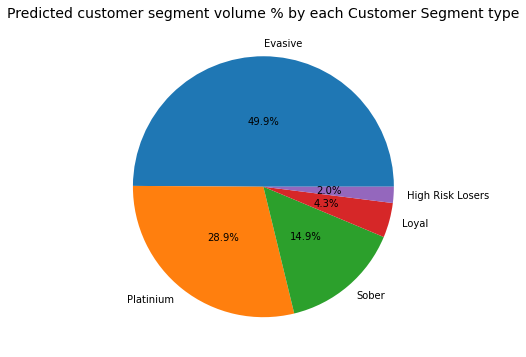

In [1429]:
#Using matplotlib
pie, ax = plt.subplots(figsize=[10,6])
labels = pie_da_new.keys()
plt.pie(x=pie_da_new, autopct="%.1f%%", labels=labels, pctdistance=0.5)
plt.title("Predicted customer segment volume % by each Customer Segment type", fontsize=14);